# Importing Libraraies

In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
# Importing Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#importing metrices
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay

# Loading CSV

In [3]:
df = pd.read_csv('spam.csv')

In [4]:
emails = df.email
label = df.label

## Splitting Training & Testing Data

In [5]:
x_train,x_test,y_train,y_test = train_test_split(emails,label,test_size=0.33,random_state=150)

## Converting text into nummbers

In [6]:
vectorizer = CountVectorizer()

In [7]:
X_train_features = vectorizer.fit_transform(x_train)
X_test_features = vectorizer.transform(x_test)

### Naive Bayes Model

In [8]:
# 1. Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_features, y_train)
nb_preds = nb_model.predict(X_test_features)
nb_acc = round((accuracy_score(y_test,nb_preds) *100),2)
print(f'Naive Bayes Accuracy: {round((accuracy_score(y_test,nb_preds) *100),2)}%')

Naive Bayes Accuracy: 98.59%


### Logistic Regression Model

In [9]:
# 2. Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train_features, y_train)
lr_preds = lr_model.predict(X_test_features)
lr_acc = round((accuracy_score(y_test,lr_preds) *100),2)
print(f'Logistic Regression Accuracy: {round((accuracy_score(y_test,lr_preds) *100),2)}%')

Logistic Regression Accuracy: 98.31%


### Decision Tree Model

In [10]:
# 3. Decision Tree Model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_features, y_train)
dt_preds = dt_model.predict(X_test_features)
dt_acc = round((accuracy_score(y_test,dt_preds) *100),2)
print(f'Decision Tree Accuracy: {round((accuracy_score(y_test,dt_preds) *100),2)}%')

Decision Tree Accuracy: 97.01%


### Random Forest Model

In [11]:
# 4. Random Forest Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_features, y_train)
rf_preds = rf_model.predict(X_test_features)
rf_acc = round((accuracy_score(y_test,rf_preds) *100),2)
print(f'Random Forest Accuracy: {round((accuracy_score(y_test,rf_preds) *100),2)}%')

Random Forest Accuracy: 97.82%


###  Support Vector Machine (SVM) Model

In [12]:
# 5. Support Vector Machine (SVM) Model
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_features, y_train)
svm_preds = svm_model.predict(X_test_features)
svm_acc = round((accuracy_score(y_test,svm_preds) *100),2)
print(f'Support Vector Machine (SVM) Accuracy: {round((accuracy_score(y_test,svm_preds) *100),2)}%')

Support Vector Machine (SVM) Accuracy: 98.48%


## Classification Report

In [13]:
print(classification_report(y_test,nb_preds))
print(classification_report(y_test,lr_preds))
print(classification_report(y_test,dt_preds))
print(classification_report(y_test,rf_preds))
print(classification_report(y_test,svm_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1574
           1       0.97      0.93      0.95       265

    accuracy                           0.99      1839
   macro avg       0.98      0.96      0.97      1839
weighted avg       0.99      0.99      0.99      1839

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1574
           1       0.98      0.90      0.94       265

    accuracy                           0.98      1839
   macro avg       0.98      0.95      0.96      1839
weighted avg       0.98      0.98      0.98      1839

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1574
           1       0.91      0.88      0.89       265

    accuracy                           0.97      1839
   macro avg       0.94      0.93      0.94      1839
weighted avg       0.97      0.97      0.97      1839

              preci

## Ploting Pie Chart

In [73]:
spam = df.label[df.label == 1].count()
not_spam = df.label[df.label == 0].count()
pie_data = [spam,not_spam]

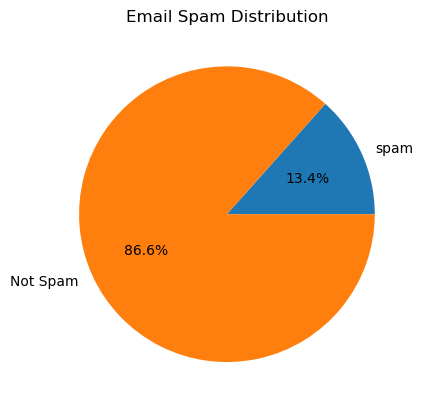

In [105]:
plt.pie(pie_data, labels=['spam','Not Spam'], autopct='%1.1f%%')
plt.title("Email Spam Distribution")
plt.show()

## Ploting Confusion Metrics for Naive Bayes Model

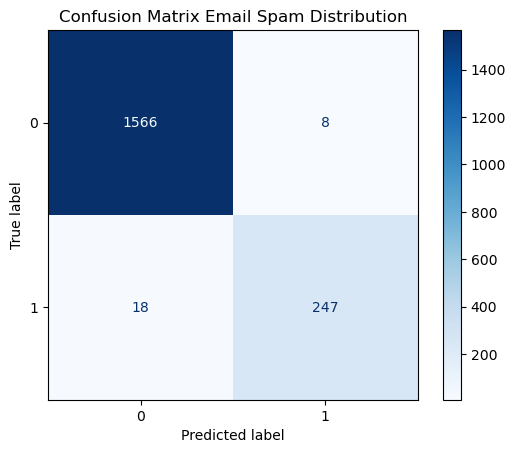

In [14]:
cm = confusion_matrix(y_test, nb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix Email Spam Distribution")
plt.show()

## Comparison of Models using Bar Chart

In [87]:
model_names = ["Naive Bayes", "Logestic Regression", "Decision Tree", "Random Forest", "SVM"]
accuracy_scores = [nb_acc, lr_acc, dt_acc, rf_acc, svm_acc]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

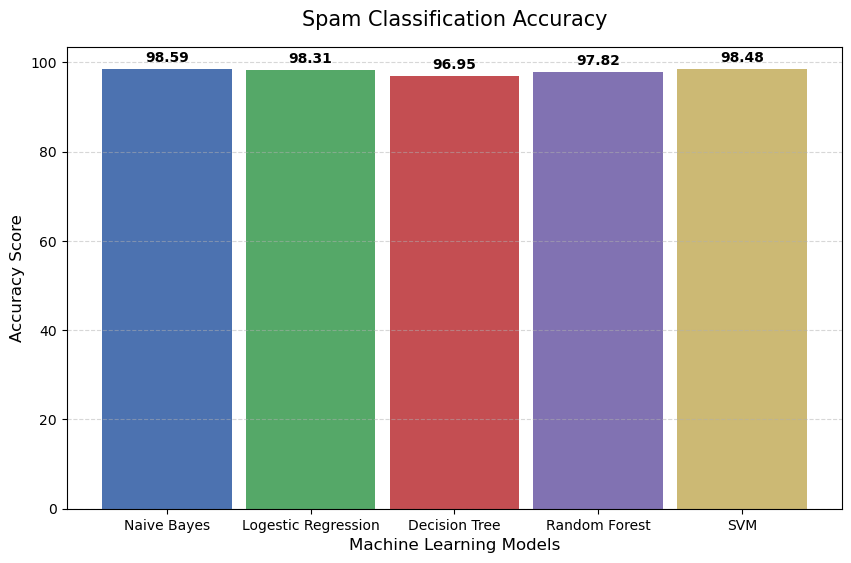

In [92]:
plt.figure(figsize=(10,6))
bars = plt.bar(model_names, accuracy_scores,color = colors, width=0.9)
plt.title("Spam Classification Accuracy",fontsize=15,pad=15)
plt.xlabel("Machine Learning Models",fontsize=12)
plt.ylabel("Accuracy Score",fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
# plt.ylim(0, 1.05)
plt.bar_label(bars, padding=3, fontweight="bold")
plt.show()

## Testing on new Email

In [16]:
email1 = ["Hi win a free iphone click now"]

# Convert email into features
email_features = vectorizer.transform(email1)

In [17]:
prediction = nb_model.predict(email_features)
if prediction[0] == 1:
    print("Spam")
else:
    print("Not spam")

Spam


## Explanation

### This project uses CountVectorizer to convert email text into numerical features and trains a Naive Bayes model to classify spam emails. The pie chart shows the distribution of spam and non-spam emails, while the confusion matrix visualizes the model’s prediction performance. The bar chart compares the accuracy of different machine learning models used for spam classification.